# EDA for Irrigation Need Predictions
This notebook collects the EDA patterns from the existing notebooks for SGD, GBC, RandomForest, AdaBoost, Logistic Regression, Decision Tree, KNN and XGBoost.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')


In [2]:
df = pd.read_csv("../data/playground-series-s6e4/train.csv")
df.head()


,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [3]:
print('Shape:', df.shape)
df.info()


Shape: (630000, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-nul

In [4]:
print(df['Irrigation_Need'].value_counts())
print('Normalized target distribution:')
print(df['Irrigation_Need'].value_counts(normalize=True))


Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64
Normalized target distribution:
Irrigation_Need
Low       0.587170
Medium    0.379483
High      0.033348
Name: proportion, dtype: float64


In [5]:
print(df.describe(include='all').T)


                            count unique        top    freq         mean   
id                       630000.0    NaN        NaN     NaN     314999.5  \
Soil_Type                  630000      4      Sandy  166509          NaN   
Soil_pH                  630000.0    NaN        NaN     NaN     6.482497   
Soil_Moisture            630000.0    NaN        NaN     NaN    37.304482   
Organic_Carbon           630000.0    NaN        NaN     NaN     0.922858   
Electrical_Conductivity  630000.0    NaN        NaN     NaN     1.744605   
Temperature_C            630000.0    NaN        NaN     NaN    26.998166   
Humidity                 630000.0    NaN        NaN     NaN     61.56318   
Rainfall_mm              630000.0    NaN        NaN     NaN  1462.207566   
Sunlight_Hours           630000.0    NaN        NaN     NaN     7.513382   
Wind_Speed_kmh           630000.0    NaN        NaN     NaN    10.375394   
Crop_Type                  630000      6  Sugarcane  108910          NaN   
Crop_Growth_

In [6]:
print(pd.crosstab(df['Season'], df['Irrigation_Need'], normalize='index'))


Irrigation_Need      High       Low    Medium
Season                                       
Kharif           0.034826  0.571349  0.393824
Rabi             0.032115  0.599770  0.368115
Zaid             0.033037  0.591088  0.375875


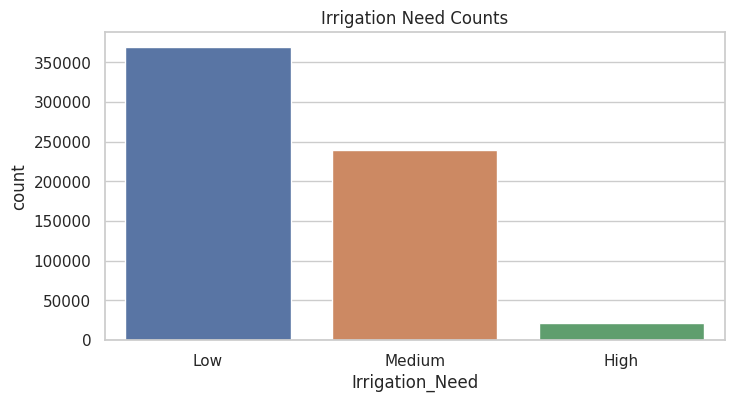

In [7]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Irrigation_Need')
plt.title('Irrigation Need Counts')
plt.show()


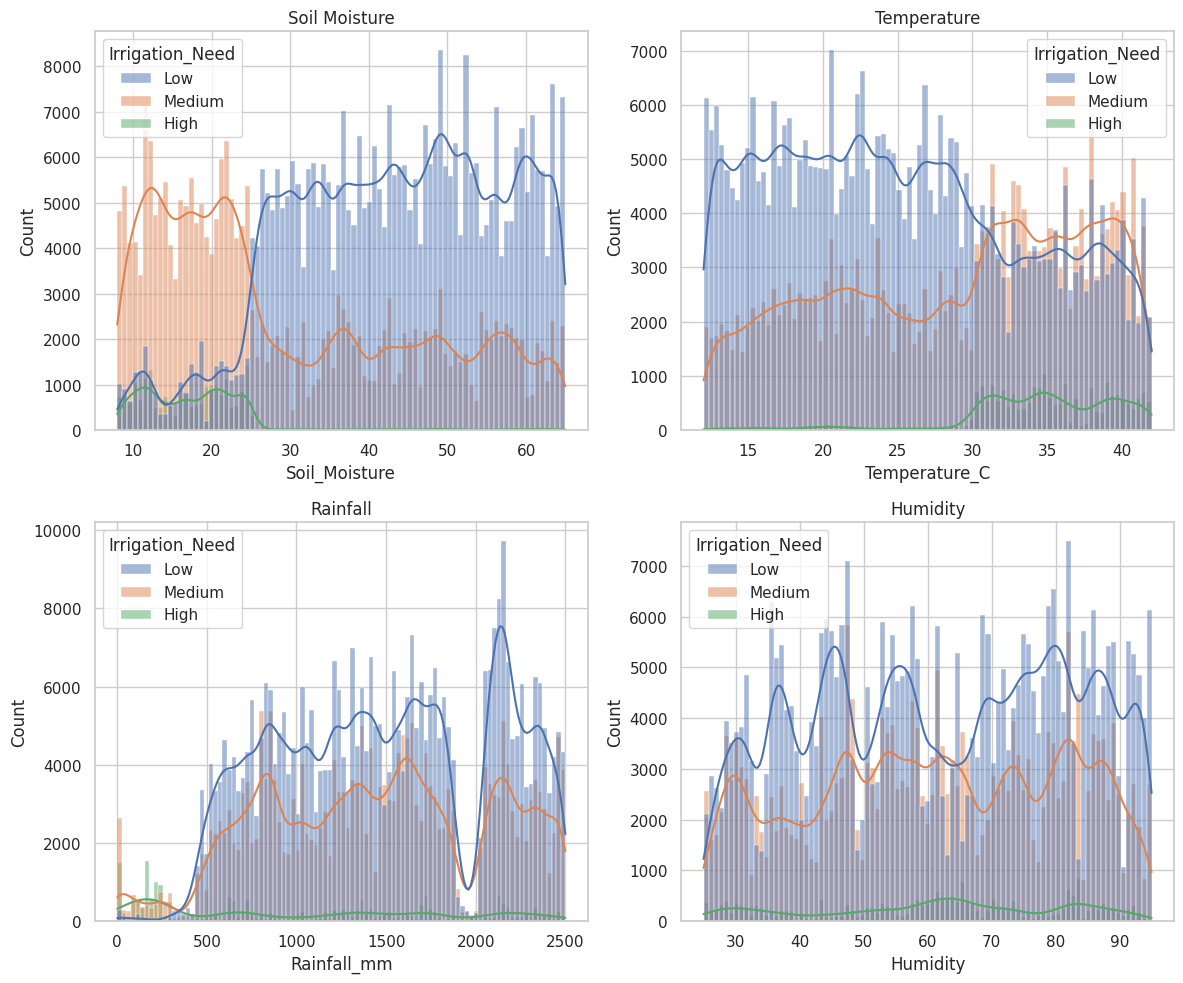

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.histplot(df, x='Soil_Moisture', hue='Irrigation_Need', ax=axes[0, 0], kde=True)
axes[0, 0].set_title('Soil Moisture')

sns.histplot(df, x='Temperature_C', hue='Irrigation_Need', ax=axes[0, 1], kde=True)
axes[0, 1].set_title('Temperature')

sns.histplot(df, x='Rainfall_mm', hue='Irrigation_Need', ax=axes[1, 0], kde=True)
axes[1, 0].set_title('Rainfall')

sns.histplot(df, x='Humidity', hue='Irrigation_Need', ax=axes[1, 1], kde=True)
axes[1, 1].set_title('Humidity')

plt.tight_layout()
plt.show()


/tmp/ipykernel_231577/854734552.py:9: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/sajit/Documents/dataScienceBootCampNeueFische/Ginger_Gradient/week8/ML_Project/ds-ml-project/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


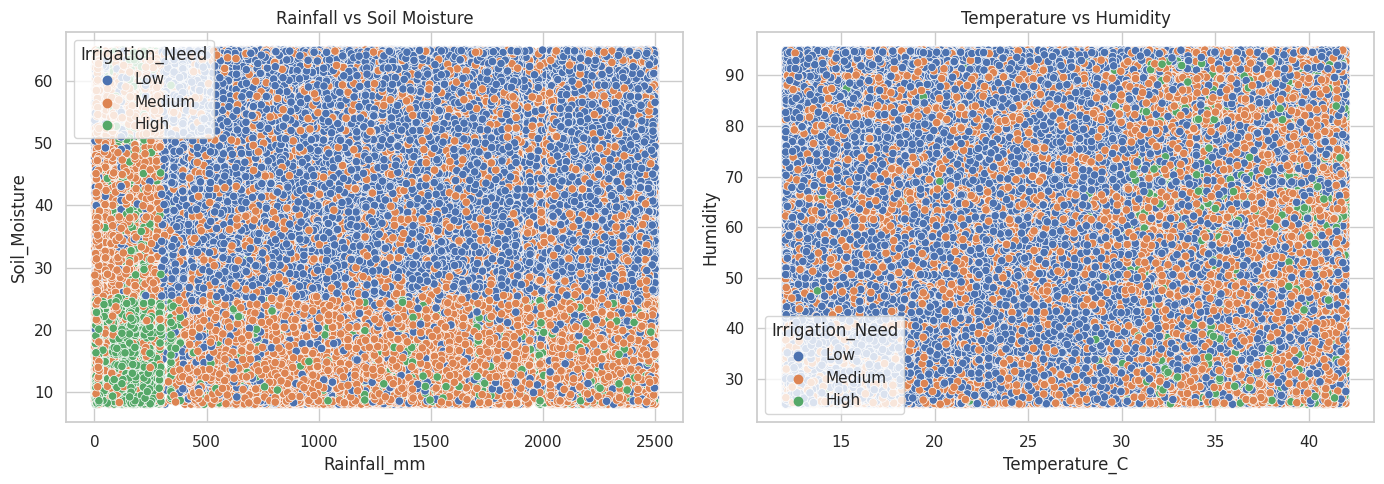

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='Rainfall_mm', y='Soil_Moisture', hue='Irrigation_Need', ax=axes[0])
axes[0].set_title('Rainfall vs Soil Moisture')

sns.scatterplot(data=df, x='Temperature_C', y='Humidity', hue='Irrigation_Need', ax=axes[1])
axes[1].set_title('Temperature vs Humidity')

plt.tight_layout()
plt.show()


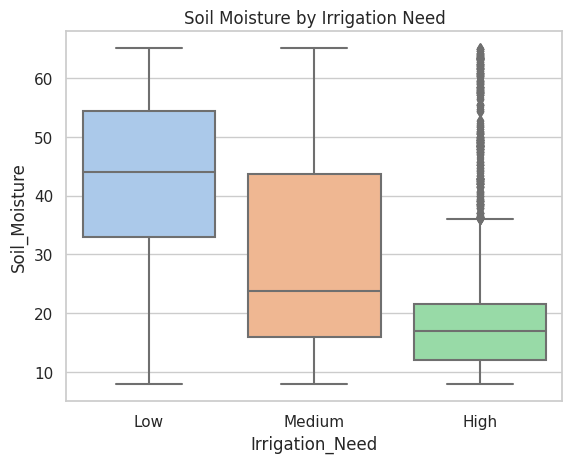

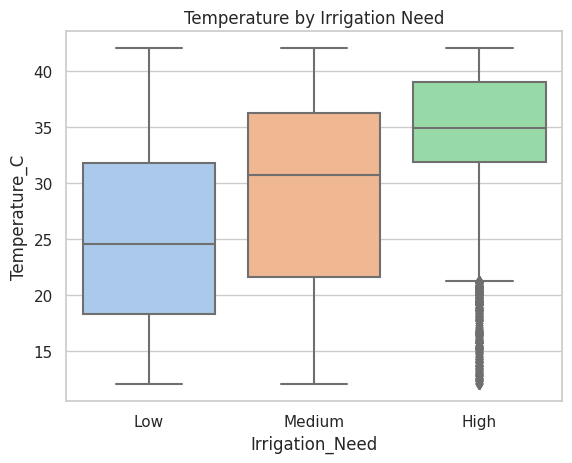

In [11]:
sns.boxplot(data=df, x='Irrigation_Need', y='Soil_Moisture', palette='pastel')
plt.title('Soil Moisture by Irrigation Need')
plt.show()

sns.boxplot(data=df, x='Irrigation_Need', y='Temperature_C', palette='pastel')
plt.title('Temperature by Irrigation Need')
plt.show()


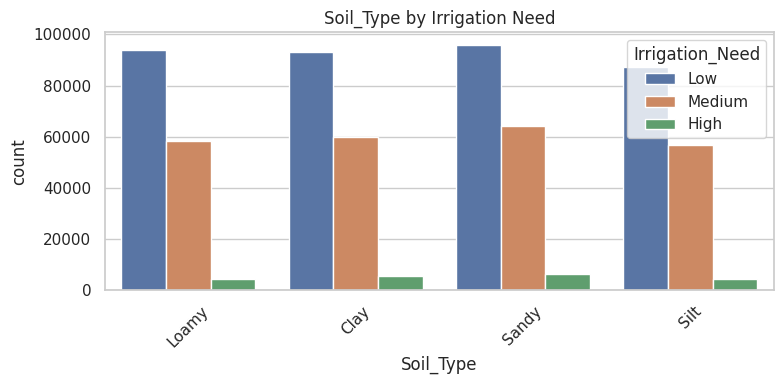

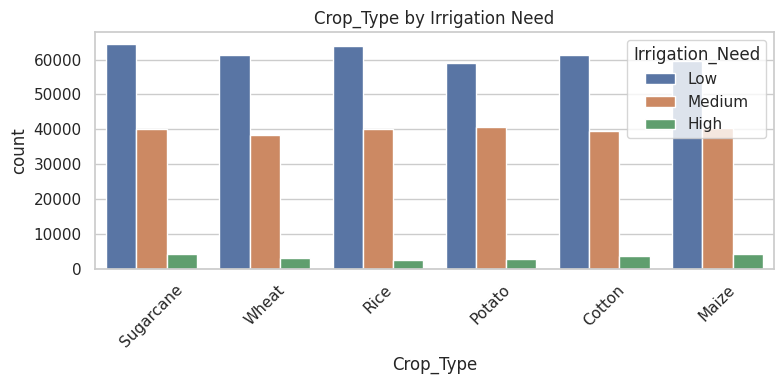

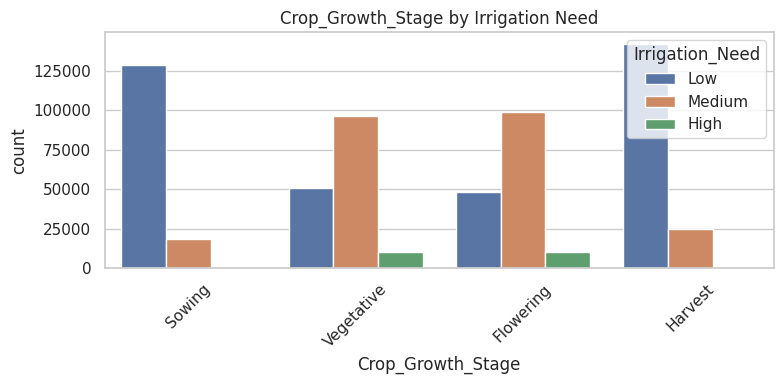

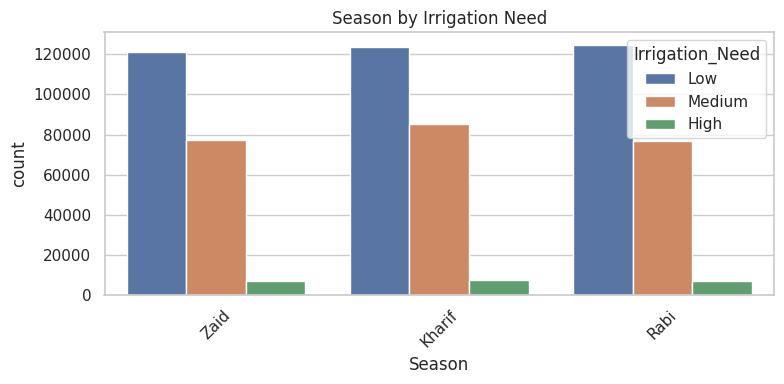

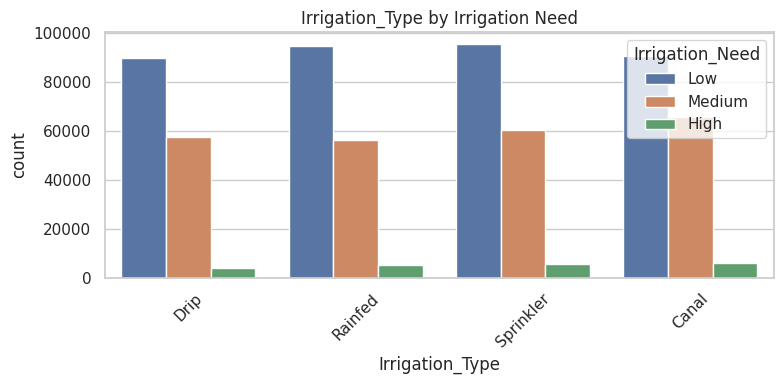

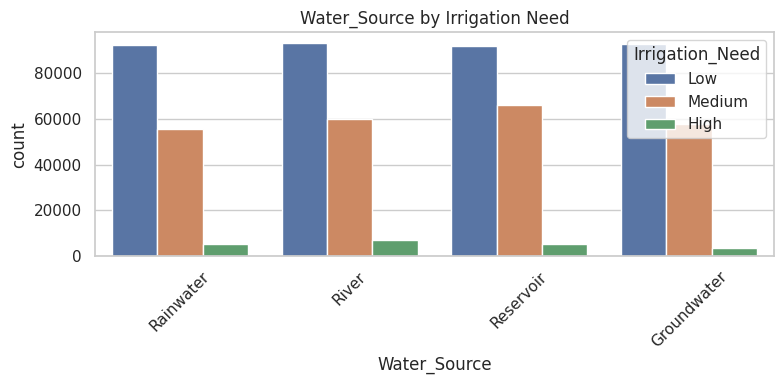

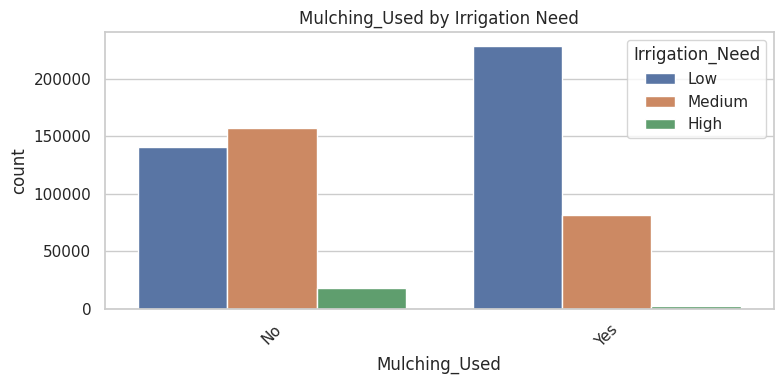

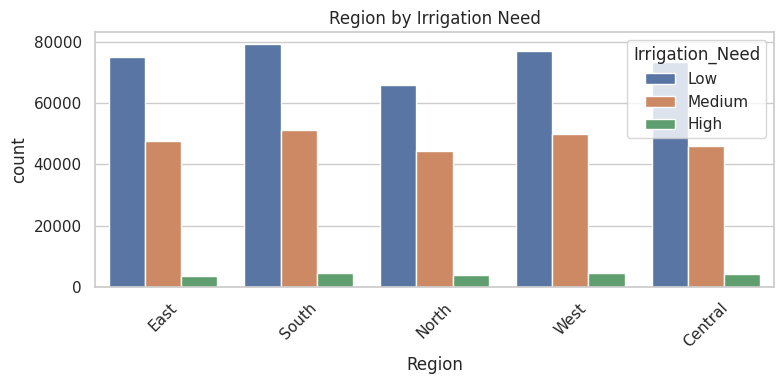

In [12]:
cat_columns = df.select_dtypes(include=['object']).columns.drop('Irrigation_Need')
for col in cat_columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, hue='Irrigation_Need')
    plt.xticks(rotation=45)
    plt.title(f'{col} by Irrigation Need')
    plt.tight_layout()
    plt.show()


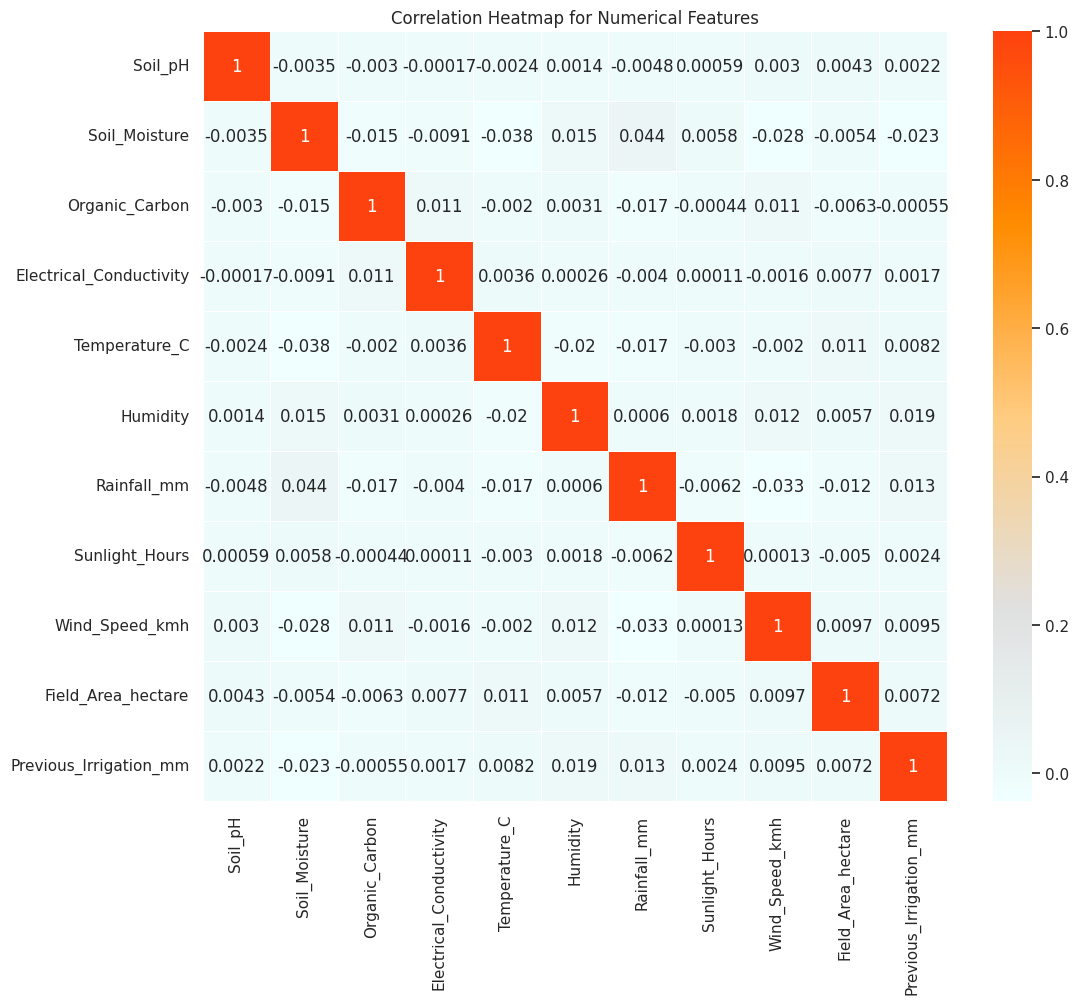

In [14]:
from matplotlib.colors import LinearSegmentedColormap

cmap = LinearSegmentedColormap.from_list('gray_to_orange', ['#F0FFFF', '#E0E0E0', '#FFCC80', '#FF8C00', '#FE420F'])
df_num = df.drop(columns=['id']).select_dtypes(include=['number'])
plt.figure(figsize=(12, 10))
sns.heatmap(df_num.corr(), annot=True, cmap=cmap, linewidths=0.5)
plt.title('Correlation Heatmap for Numerical Features')
plt.show()


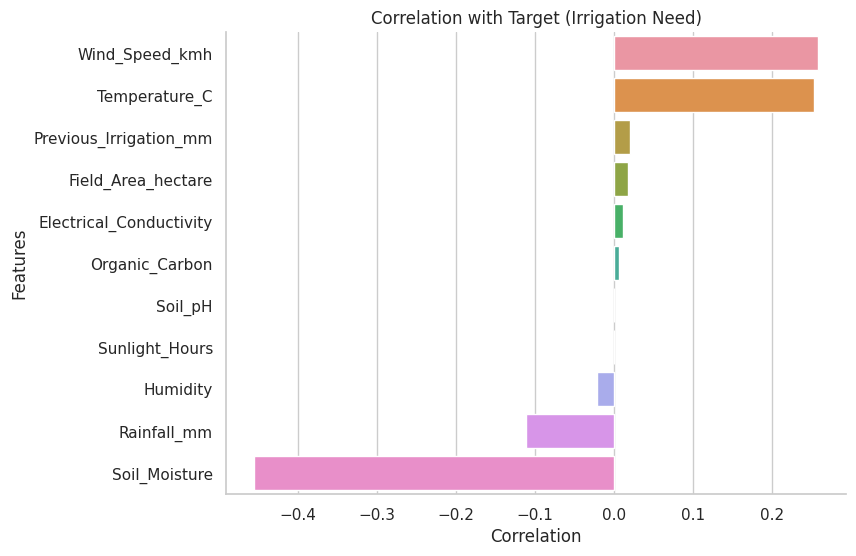

In [16]:
df_corr = df.drop(columns=["id"])

mapping = {"Low": 0, "Medium": 1, "High": 2}
df_corr["Irrigation_Need_Encoded"] = df_corr["Irrigation_Need"].map(mapping)

# correlatio with target
corr_target = df_corr.corr(numeric_only=True)["Irrigation_Need_Encoded"].sort_values(ascending=False)
corr_target = corr_target.drop("Irrigation_Need_Encoded")

plt.figure(figsize=(8, 6))
sns.barplot(x=corr_target.values, y=corr_target.index)
sns.despine()
plt.title("Correlation with Target (Irrigation Need)")
plt.xlabel("Correlation")
plt.ylabel("Features")
plt.show()
